# ArchiGAN — Prompter cGANGénère des plans d'appartement à partir d'un **prompt en langage naturel**.Pipeline : `texte → parser → condition → cGAN → snap → placement compact → rendu`

## Cellule 0 — Fondations

In [ ]:
# =====================================================================
# CELLULE 0 - FONDATIONS DU PROJET (dicts + fonctions procedurales)
# =====================================================================
# But : poser TOUS les elements non-ML dont le GAN aura besoin :
#   - Le vocabulaire des pieces (room_ids, room_sizes, room_adjacencies)
#   - Le pipeline procedural de placement (place_rooms, ...)
#   - L'evaluation de la qualite (evaluate_adjacency_compliance)
#   - Le rendu image (create_plan_image, visualize_and_save_plan)
#
# Cette cellule ne contient PAS de reseau de neurones - c'est le socle
# metier. Les cellules 1 a 5 s'appuieront dessus.
# =====================================================================

import os
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

# --- 1. Vocabulaire des pieces ---------------------------------------
# On garde exactement le meme mapping que dans la version originale
# du notebook (pour rester compatible si tu reveux plus tard reprendre
# du code existant).
room_ids = {
    "vide": 0, "salon": 1, "chambre": 2, "douche": 3, "toilettes": 4,
    "couloir": 5, "bureau": 6, "cuisine": 8, "porte": 9,
    "exterieur": 11, "balcon": 12, "dressing": 13
}
id_to_room = {v: k for k, v in room_ids.items()}

# Tailles (largeur, hauteur) en cellules de grille - pas en pixels
room_sizes = {
    0: (8, 8),      # vide
    1: (14, 16),    # salon (grand)
    2: (10, 12),    # chambre
    3: (6, 8),      # douche
    4: (4, 6),      # toilettes
    5: (3, 20),     # couloir (long et etroit)
    6: (8, 10),     # bureau
    8: (10, 10),    # cuisine
    9: (1, 1),      # porte
    11: (1, 1),     # exterieur
    12: (6, 10),    # balcon
    13: (4, 6)      # dressing
}

# Regles d'adjacence : quelles pieces peuvent/doivent etre voisines
# Chaque tuple = (nom_voisin, probabilite qu'on tente l'adjacence)
room_adjacencies = {
    "salon":     [("cuisine", 0.7), ("couloir", 0.9), ("balcon", 0.7), ("exterieur", 0.8)],
    "couloir":   [("salon", 0.9), ("chambre", 0.95), ("cuisine", 0.7),
                  ("douche", 0.8), ("bureau", 0.6), ("toilettes", 0.5), ("dressing", 0.4)],
    "chambre":   [("couloir", 0.9), ("douche", 0.7), ("dressing", 0.6), ("balcon", 0.3)],
    "cuisine":   [("salon", 0.7), ("couloir", 0.7), ("balcon", 0.2)],
    "douche":    [("chambre", 0.7), ("couloir", 0.8)],
    "toilettes": [("couloir", 0.9), ("douche", 0.4)],
    "bureau":    [("couloir", 0.8), ("salon", 0.4)],
    "dressing":  [("chambre", 0.8), ("couloir", 0.5)],
    "balcon":    [("salon", 0.7), ("chambre", 0.4), ("cuisine", 0.2)],
    "exterieur": [("salon", 0.9)]
}

TARGET_IMAGE_SIZE = 512  # Taille finale des images generees en pixels


# --- 2. Utilitaires de placement -------------------------------------

def get_adjacent_rooms(room_name):
    """Retourne la liste des pieces adjacentes possibles pour room_name,
    en filtrant selon les probabilites (donc resultat stochastique)."""
    possible = room_adjacencies.get(room_name, [])
    return [r[0] for r in possible if random.random() < r[1]]


def is_valid_placement(grid, x, y, w, h, ignore_ids=[]):
    """Verifie qu'un rectangle (x, y, w, h) peut etre pose sur la grille
    sans depasser les bords ni empieter sur une piece existante."""
    h_grid, w_grid = grid.shape
    if x < 0 or y < 0 or x + w > w_grid or y + h > h_grid:
        return False
    for r in range(y, y + h):
        for c in range(x, x + w):
            if grid[r, c] != room_ids["vide"] and grid[r, c] not in ignore_ids:
                return False
    return True


def place_room_and_door(grid, new_room_pos, parent_room_pos):
    """Essaye de percer une porte entre deux pieces adjacentes.
    Retourne (succes, dict_info_porte)."""
    nx, ny, nw, nh = new_room_pos
    px, py, pw, ph = parent_room_pos

    if nx == px + pw:                    # new a droite de parent
        overlap_start, overlap_end = max(ny, py), min(ny + nh, py + ph)
        orientation, side = 'vertical', 'right'
        fixed_new, fixed_parent = nx, px + pw - 1
    elif px == nx + nw:                  # new a gauche de parent
        overlap_start, overlap_end = max(ny, py), min(ny + nh, py + ph)
        orientation, side = 'vertical', 'left'
        fixed_new, fixed_parent = nx + nw - 1, px
    elif ny == py + ph:                  # new en dessous de parent
        overlap_start, overlap_end = max(nx, px), min(nx + nw, px + pw)
        orientation, side = 'horizontal', 'bottom'
        fixed_new, fixed_parent = ny, py + ph - 1
    elif py == ny + nh:                  # new au dessus de parent
        overlap_start, overlap_end = max(nx, px), min(nx + nw, px + pw)
        orientation, side = 'horizontal', 'top'
        fixed_new, fixed_parent = ny + nh - 1, py
    else:
        return False, None

    door_size = 2
    if overlap_start >= overlap_end - door_size + 1:
        return False, None

    door_pos = random.randint(overlap_start, overlap_end - door_size)

    # On marque les pixels de porte dans la grille pour que le rendu
    # puisse creer l'ouverture visuelle plus tard
    if orientation == 'vertical':
        for r in range(door_pos, door_pos + door_size):
            if 0 <= r < grid.shape[0]:
                if 0 <= fixed_new < grid.shape[1]:
                    grid[r, fixed_new] = room_ids["porte"]
                if 0 <= fixed_parent < grid.shape[1]:
                    grid[r, fixed_parent] = room_ids["porte"]
        door_info = {'pos': (fixed_new, door_pos), 'size': door_size,
                     'orientation': orientation, 'side': side}
    else:  # horizontal
        for c in range(door_pos, door_pos + door_size):
            if 0 <= c < grid.shape[1]:
                if 0 <= fixed_new < grid.shape[0]:
                    grid[fixed_new, c] = room_ids["porte"]
                if 0 <= fixed_parent < grid.shape[0]:
                    grid[fixed_parent, c] = room_ids["porte"]
        door_info = {'pos': (door_pos, fixed_new), 'size': door_size,
                     'orientation': orientation, 'side': side}

    return True, door_info


def place_rooms(grid, pieces_to_place):
    """Place les pieces sur la grille en tenant compte des adjacences.
    C'est l'algorithme glouton central du projet.

    Args:
      grid : np.array 2D initialisee a zero
      pieces_to_place : dict {name: count}, ex {'salon': 1, 'chambre': 2, ...}

    Returns:
      grid modifiee, liste des pieces placees, liste des portes creees.
    """
    placed_rooms, placed_doors = [], []
    h, w = grid.shape

    # On construit la liste ordonnee des pieces a placer (par priorite)
    rooms_list = []
    for name, count in pieces_to_place.items():
        if name in ['vide', 'porte', 'exterieur']:
            continue
        rid = room_ids[name]
        priority = 0 if name == 'salon' else (1 if name == 'couloir'
                    else (2 if name in ['cuisine', 'chambre'] else 3))
        w_room, h_room = room_sizes[rid]
        orientations = [(w_room, h_room)]
        if name == 'couloir' and w_room != h_room:
            orientations.append((h_room, w_room))
        for _ in range(count):
            rooms_list.append({'id': rid, 'name': name,
                               'priority': priority,
                               'orientations': orientations})
    rooms_list.sort(key=lambda x: x['priority'])

    # Placement iteratif
    for room_to_place in rooms_list:
        room_id = room_to_place['id']
        room_name = room_to_place['name']
        placed = False

        # 1ere piece : au centre de la grille
        if not placed_rooms:
            for room_w, room_h in room_to_place['orientations']:
                cx, cy = (w - room_w) // 2, (h - room_h) // 2
                if is_valid_placement(grid, cx, cy, room_w, room_h):
                    grid[cy:cy+room_h, cx:cx+room_w] = room_id
                    placed_rooms.append({
                        'id': room_id, 'pos': (cx, cy, room_w, room_h),
                        'name': room_name, 'unique_id': f"{room_name}_0"
                    })
                    placed = True
                    break
            continue

        # Autres pieces : on cherche un parent adjacent legal
        possible_parents = [p for p in placed_rooms
                            if room_name in get_adjacent_rooms(p['name'])
                            or p['name'] in get_adjacent_rooms(room_name)]
        if not possible_parents:
            possible_parents = placed_rooms.copy()
        random.shuffle(possible_parents)

        for parent in possible_parents:
            px, py, pw, ph = parent['pos']
            sides = ['top', 'right', 'bottom', 'left']
            random.shuffle(sides)
            for side in sides:
                for room_w, room_h in room_to_place['orientations']:
                    nx, ny = -1, -1
                    min_overlap = 2
                    if side == 'top':
                        ny = py - room_h
                        s, e = (max(0, px - room_w + min_overlap),
                                min(w - room_w, px + pw - min_overlap))
                    elif side == 'right':
                        nx = px + pw
                        s, e = (max(0, py - room_h + min_overlap),
                                min(h - room_h, py + ph - min_overlap))
                    elif side == 'bottom':
                        ny = py + ph
                        s, e = (max(0, px - room_w + min_overlap),
                                min(w - room_w, px + pw - min_overlap))
                    elif side == 'left':
                        nx = px - room_w
                        s, e = (max(0, py - room_h + min_overlap),
                                min(h - room_h, py + ph - min_overlap))
                    if s > e:
                        continue
                    for _ in range(10):
                        cur_nx = random.randint(s, e) if side in ['top', 'bottom'] else nx
                        cur_ny = random.randint(s, e) if side in ['left', 'right'] else ny
                        cur_nx = max(0, min(w - room_w, cur_nx))
                        cur_ny = max(0, min(h - room_h, cur_ny))
                        if is_valid_placement(grid, cur_nx, cur_ny, room_w, room_h):
                            grid[cur_ny:cur_ny+room_h,
                                 cur_nx:cur_nx+room_w] = room_id
                            count_same = len([p for p in placed_rooms
                                              if p['name'] == room_name])
                            info = {
                                'id': room_id,
                                'pos': (cur_nx, cur_ny, room_w, room_h),
                                'name': room_name,
                                'unique_id': f"{room_name}_{count_same}"
                            }
                            placed_rooms.append(info)
                            ok, door = place_room_and_door(grid, info['pos'],
                                                            parent['pos'])
                            if ok:
                                door['connected_rooms'] = (parent['unique_id'],
                                                            info['unique_id'])
                                placed_doors.append(door)
                            placed = True
                            break
                    if placed: break
                if placed: break
            if placed: break

    # Marquer la bordure exterieure de la grille
    for y in range(h):
        for x in range(w):
            if x == 0 or x == w-1 or y == 0 or y == h-1:
                if grid[y, x] == room_ids["vide"]:
                    grid[y, x] = room_ids["exterieur"]

    return grid, placed_rooms, placed_doors


# --- 3. Evaluation de la qualite d'un plan ---------------------------

def evaluate_adjacency_compliance(placed_rooms, placed_doors):
    """Retourne un float entre 0 et 1 : proportion de pieces qui ont
    au moins une adjacence LEGALE (via une porte) selon room_adjacencies.
    """
    if not placed_rooms:
        return 0.0
    # Graphe des connexions via les portes
    graph = {r['unique_id']: [] for r in placed_rooms}
    for d in placed_doors:
        if 'connected_rooms' in d:
            r1, r2 = d['connected_rooms']
            if r1 in graph and r2 in graph:
                graph[r1].append(r2)
                graph[r2].append(r1)
    # Comptage des pieces conformes
    compliant = 0
    for room in placed_rooms:
        name = room['name']
        if name not in room_adjacencies:
            compliant += 1
            continue
        neighbor_names = []
        for cid in graph.get(room['unique_id'], []):
            cr = next((r for r in placed_rooms if r['unique_id'] == cid), None)
            if cr:
                neighbor_names.append(cr['name'])
        allowed = [x[0] for x in room_adjacencies[name]]
        if any(a in allowed for a in neighbor_names):
            compliant += 1
    return compliant / len(placed_rooms)


# --- 4. Rendu image ---------------------------------------------------

def create_plan_image(grid, room_ids_map, placed_doors,
                       image_size=TARGET_IMAGE_SIZE):
    """Transforme la grille numpy en image PIL noir et blanc.
    Fond blanc, murs noirs, portes = trous dans les murs."""
    grid_dim = grid.shape[0]
    cell = image_size // grid_dim
    canvas = Image.new('L', (image_size, image_size), 255)
    draw = ImageDraw.Draw(canvas)
    WALL, ROOM = 0, 255
    INT_W, EXT_W = 2, 4

    # Fond des pieces en blanc (rempli)
    for r in range(grid_dim):
        for c in range(grid_dim):
            if grid[r, c] != room_ids_map["exterieur"]:
                x0, y0 = c*cell, r*cell
                draw.rectangle([(x0, y0), (x0+cell, y0+cell)], fill=ROOM)

    # Murs internes (entre deux cellules d'ids differents)
    for r in range(grid_dim):
        for c in range(grid_dim):
            cur = grid[r, c]
            if c < grid_dim-1 and cur != grid[r, c+1]:
                x = (c+1)*cell
                draw.line([(x, r*cell), (x, (r+1)*cell)], fill=WALL, width=INT_W)
            if r < grid_dim-1 and cur != grid[r+1, c]:
                y = (r+1)*cell
                draw.line([(c*cell, y), ((c+1)*cell, y)], fill=WALL, width=INT_W)
            # Murs exterieurs (bordure de la grille, pour les cellules
            # qui ne sont PAS de l'exterieur)
            if cur != room_ids_map["exterieur"]:
                if r == 0:
                    draw.line([(c*cell, 0), ((c+1)*cell, 0)],
                              fill=WALL, width=EXT_W)
                if c == 0:
                    draw.line([(0, r*cell), (0, (r+1)*cell)],
                              fill=WALL, width=EXT_W)
                if r == grid_dim-1:
                    draw.line([(c*cell, image_size-EXT_W+1),
                               ((c+1)*cell, image_size-EXT_W+1)],
                              fill=WALL, width=EXT_W)
                if c == grid_dim-1:
                    draw.line([(image_size-EXT_W+1, r*cell),
                               (image_size-EXT_W+1, (r+1)*cell)],
                              fill=WALL, width=EXT_W)

    # Portes = petits carres blancs qui "cassent" les murs
    door_w = cell // 3
    for d in placed_doors:
        gc, gr = d['pos']
        orientation, side = d['orientation'], d['side']
        if orientation == 'horizontal':
            wall_y = (gr+1)*cell if side == 'bottom' else gr*cell
            x0 = gc*cell + (cell-door_w)//2
            draw.rectangle([(x0, wall_y-EXT_W//2),
                            (x0+door_w, wall_y+EXT_W//2)], fill=ROOM)
        else:
            wall_x = (gc+1)*cell if side == 'right' else gc*cell
            y0 = gr*cell + (cell-door_w)//2
            draw.rectangle([(wall_x-EXT_W//2, y0),
                            (wall_x+EXT_W//2, y0+door_w)], fill=ROOM)

    return canvas


def visualize_and_save_plan(grid, placed_rooms, placed_doors, title="",
                             save_path=None, show_image=True):
    """Affiche/sauve le plan avec les labels de pieces annotes."""
    pil_img = create_plan_image(grid, room_ids, placed_doors)
    h_grid, w_grid = grid.shape

    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(pil_img, cmap='gray')
    ax.set_title(title, fontsize=14, pad=15)
    ax.axis('off')

    scale_x = TARGET_IMAGE_SIZE / w_grid
    scale_y = TARGET_IMAGE_SIZE / h_grid
    for room in placed_rooms:
        rid = room['id']
        name = id_to_room.get(rid, "")
        if name in ["vide", "porte", "exterieur"]:
            continue
        x, y, w, h = room['pos']
        ax.text((x + w/2) * scale_x, (y + h/2) * scale_y,
                name.capitalize(), ha='center', va='center',
                fontsize=8, color='black', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.3', fc='white',
                          ec='none', alpha=0.75))
    if save_path:
        pil_img.save(save_path)
        print(f"Plan sauve : {save_path}")
    if show_image:
        plt.show()
    else:
        plt.close(fig)


# --- 5. Test rapide pour verifier que tout fonctionne ----------------
print("Test rapide de la cellule 0...")
random.seed(42)
np.random.seed(42)
test_pieces = {"salon": 1, "cuisine": 1, "chambre": 2, "couloir": 1,
                "douche": 1, "toilettes": 1}
grid_test = np.zeros((60, 60), dtype=int)
grid_test, placed, doors = place_rooms(grid_test, test_pieces)
score = evaluate_adjacency_compliance(placed, doors)
print(f"  Pieces placees : {len(placed)}/{sum(test_pieces.values())}")
print(f"  Portes creees  : {len(doors)}")
print(f"  Score adjacence: {score:.2f}")
print("\n[Cellule 0 OK] Fondations pretes.")

Test rapide de la cellule 0...
  Pieces placees : 7/7
  Portes creees  : 6
  Score adjacence: 1.00

[Cellule 0 OK] Fondations pretes.


In [ ]:
"""
archi_render.py  --  Rendu minimaliste noir & blanc d'un plan 2D.
A copier dans la CELLULE 0 (remplace create_plan_image/visualize_and_save_plan).

Noir et blanc. Murs pleins, portes a convention architecturale (vantail 90deg
+ arc de debattement), nom de piece seul. Echelle : 1 cellule = 30 cm.
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

CELL_CM = 30
INK   = "#111111"   # noir principal
PAPER = "#FFFFFF"
FILL  = "#FFFFFF"   # interieur des pieces (blanc)

GENERATIVE = ["salon", "chambre", "douche", "toilettes", "couloir",
              "bureau", "cuisine", "balcon", "dressing"]


def render_architectural_plan(grid, placed_rooms, placed_doors,
                              room_ids_map, id_to_room_map,
                              title="Plan", save_path=None, show=True):
    H, W = grid.shape

    fig, ax = plt.subplots(figsize=(11, 11), facecolor=PAPER)
    ax.set_facecolor(PAPER)

    # Cadrage serre sur la zone batie
    ys, xs = np.where(grid != room_ids_map["exterieur"])
    if len(xs):
        m = 2
        x0, x1 = xs.min() - m, xs.max() + 1 + m
        y0, y1 = ys.min() - m, ys.max() + 1 + m
        span = max(x1 - x0, y1 - y0)
        # Centrer dans un carre pour ne pas deformer
        cx, cy = (x0 + x1) / 2, (y0 + y1) / 2
        x0, x1 = cx - span / 2, cx + span / 2
        y0, y1 = cy - span / 2, cy + span / 2
    else:
        x0, x1, y0, y1 = 0, W, 0, H
    ax.set_xlim(x0, x1); ax.set_ylim(y1, y0)
    ax.set_aspect('equal'); ax.axis('off')

    # 1) Interieur blanc des pieces (masque le fond)
    for r in placed_rooms:
        x, y, w, h = r['pos']
        ax.add_patch(Rectangle((x, y), w, h, facecolor=FILL,
                     edgecolor='none', zorder=1))

    # 2) Cloisons : contour de chaque piece (trait moyen)
    for r in placed_rooms:
        x, y, w, h = r['pos']
        ax.add_patch(Rectangle((x, y), w, h, facecolor='none',
                     edgecolor=INK, linewidth=1.6, zorder=3,
                     joinstyle='miter'))

    # 3) Murs porteurs : bords donnant sur l'exterieur (trait epais)
    def ext(rr, cc):
        for a in rr:
            for b in cc:
                if 0 <= a < H and 0 <= b < W:
                    if grid[a, b] == room_ids_map["exterieur"]:
                        return True
                else:
                    return True
        return False

    for r in placed_rooms:
        x, y, w, h = r['pos']
        if ext([y-1], range(x, x+w)):
            ax.plot([x, x+w], [y, y], color=INK, lw=5, zorder=4,
                    solid_capstyle='projecting')
        if ext([y+h], range(x, x+w)):
            ax.plot([x, x+w], [y+h, y+h], color=INK, lw=5, zorder=4,
                    solid_capstyle='projecting')
        if ext(range(y, y+h), [x-1]):
            ax.plot([x, x], [y, y+h], color=INK, lw=5, zorder=4,
                    solid_capstyle='projecting')
        if ext(range(y, y+h), [x+w]):
            ax.plot([x+w, x+w], [y, y+h], color=INK, lw=5, zorder=4,
                    solid_capstyle='projecting')

    # 4) Portes : convention archi = ouverture nette + vantail a 90deg + arc
    import math
    def door(hinge, along, openv, size):
        """hinge: point du gond. along: vecteur unitaire le long du mur
        (direction ouverture du vantail au repos = ferme). openv: vecteur
        unitaire perpendiculaire, cote ou la porte s'ouvre."""
        ax_, ay = along
        ox, oy = openv
        # Vantail dessine OUVERT a 90deg -> il pointe selon openv, longueur=size
        leaf_end = (hinge[0] + ox * size, hinge[1] + oy * size)
        ax.plot([hinge[0], leaf_end[0]], [hinge[1], leaf_end[1]],
                color=INK, lw=1.8, zorder=7)
        # Arc de debattement : du vantail ouvert (openv) vers le mur (along)
        pts = []
        for k in range(25):
            t = (k / 24) * (math.pi / 2)
            # interpolation angulaire de openv (t=0) vers along (t=pi/2)
            vx = math.cos(t) * ox + math.sin(t) * ax_
            vy = math.cos(t) * oy + math.sin(t) * ay
            pts.append((hinge[0] + vx * size, hinge[1] + vy * size))
        ax.plot([p[0] for p in pts], [p[1] for p in pts],
                color=INK, lw=0.7, zorder=7)

    # Helper : une cellule appartient-elle a une piece (pas vide/exterieur) ?
    def is_room_cell(cc, rr):
        if 0 <= rr < H and 0 <= cc < W:
            v = grid[rr, cc]
            return v != room_ids_map["exterieur"] and v != room_ids_map["vide"]
        return False

    for d in placed_doors:
        gc, gr = d['pos']; ds = d.get('size', 2)

        if d['orientation'] == 'vertical':
            # Mur vertical. Le 'fixed' de la porte = x du bord partage.
            wx = gc
            # Trou dans le mur
            ax.plot([wx, wx], [gr, gr+ds], color=PAPER, lw=8, zorder=6,
                    solid_capstyle='butt')
            # Y a-t-il une piece a gauche (wx-1) et/ou a droite (wx) du mur ?
            mid = gr + ds // 2
            room_left = is_room_cell(wx - 1, mid)
            room_right = is_room_cell(wx, mid)
            # Le vantail s'ouvre vers une piece. On prefere la pièce de
            # gauche par convention ; sinon droite.
            if room_left:
                openv = (-1, 0)
            elif room_right:
                openv = (1, 0)
            else:
                openv = (-1, 0)
            # Gond : on le met en haut ou en bas selon la place verticale.
            # On regarde si au-dessus (gr-1) ou en-dessous (gr+ds) c'est libre
            # dans la piece d'ouverture, pour eviter que l'arc sorte.
            open_col = wx - 1 if openv[0] < 0 else wx
            up_ok = is_room_cell(open_col, gr - 1)
            down_ok = is_room_cell(open_col, gr + ds)
            if down_ok:
                hinge = (wx, gr + ds); along = (0, -1)
            else:
                hinge = (wx, gr); along = (0, 1)
            door(hinge, along, openv, ds)

        else:
            wy = gr
            ax.plot([gc, gc+ds], [wy, wy], color=PAPER, lw=8, zorder=6,
                    solid_capstyle='butt')
            mid = gc + ds // 2
            room_up = is_room_cell(mid, wy - 1)
            room_down = is_room_cell(mid, wy)
            if room_down:
                openv = (0, 1)
            elif room_up:
                openv = (0, -1)
            else:
                openv = (0, 1)
            open_row = wy - 1 if openv[1] < 0 else wy
            left_ok = is_room_cell(gc - 1, open_row)
            right_ok = is_room_cell(gc + ds, open_row)
            if right_ok:
                hinge = (gc, wy); along = (1, 0)
            else:
                hinge = (gc + ds, wy); along = (-1, 0)
            door(hinge, along, openv, ds)

    # 5) Nom de piece seul
    for r in placed_rooms:
        x, y, w, h = r['pos']
        ax.text(x + w/2, y + h/2, r['name'].upper(),
                ha='center', va='center', fontsize=8.5, color=INK,
                zorder=10, family='monospace')

    # Titre discret
    n_ch = sum(1 for r in placed_rooms if r['name'] == 'chambre')
    typo = f"T{n_ch+1}" if n_ch > 0 else "STUDIO"
    ax.set_title(f"{title.upper()}   —   {typo}",
                 fontsize=13, color=INK, family='monospace', pad=18)

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor=PAPER)
        print(f"Plan sauve : {save_path}")
    if show:
        plt.show()
    else:
        plt.close(fig)
    return fig


## Cellule 1 — Placement compact

In [ ]:
"""
place_rooms_v2.py -- Ameliorations de placement : compaction + recentrage.

Ces fonctions s'appliquent APRES place_rooms() existant. Elles prennent
la liste placed_rooms et la retravaillent, puis on reconstruit la grille
et les portes proprement.

Principe :
  1. compact_rooms  : pousse iterativement chaque piece vers le centre de
     masse pour coller les trous (facon "gravite douce").
  2. recenter_rooms : translate tout l'ensemble pour centrer la bounding box
     dans la grille.
  3. rebuild_grid_and_doors : redessine la grille + recalcule les portes
     entre pieces devenues adjacentes.
"""

import numpy as np
import random


def rects_overlap(a, b):
    """a, b = (x, y, w, h). True si les deux rectangles se chevauchent."""
    ax, ay, aw, ah = a
    bx, by, bw, bh = b
    return not (ax + aw <= bx or bx + bw <= ax or
                ay + ah <= by or by + bh <= ay)


def can_place_at(room, new_pos, others, grid_w, grid_h):
    """Verifie qu'une piece a new_pos ne sort pas de la grille et ne
    chevauche aucune autre piece."""
    nx, ny, w, h = new_pos
    if nx < 0 or ny < 0 or nx + w > grid_w or ny + h > grid_h:
        return False
    for o in others:
        if rects_overlap(new_pos, o['pos']):
            return False
    return True


def compact_rooms(placed_rooms, grid_w, grid_h, iterations=200):
    """Pousse chaque piece d'un pas vers le centre de masse global,
    tant que ca ne cree pas de collision. Colle les trous."""
    rooms = [dict(r) for r in placed_rooms]  # copie

    for _ in range(iterations):
        # Centre de masse de l'ensemble
        cx = np.mean([r['pos'][0] + r['pos'][2] / 2 for r in rooms])
        cy = np.mean([r['pos'][1] + r['pos'][3] / 2 for r in rooms])

        moved = False
        # On traite les pieces de la plus eloignee du centre a la plus proche
        order = sorted(range(len(rooms)), key=lambda i: -(
            (rooms[i]['pos'][0] + rooms[i]['pos'][2]/2 - cx) ** 2 +
            (rooms[i]['pos'][1] + rooms[i]['pos'][3]/2 - cy) ** 2))

        for i in order:
            r = rooms[i]
            x, y, w, h = r['pos']
            rc_x, rc_y = x + w / 2, y + h / 2
            # Direction vers le centre (pas de 1 cellule sur l'axe dominant)
            dx = np.sign(cx - rc_x)
            dy = np.sign(cy - rc_y)
            others = [rooms[j] for j in range(len(rooms)) if j != i]

            # Essayer de bouger sur x puis sur y (mouvement Manhattan)
            for (mx, my) in [(dx, 0), (0, dy)]:
                if mx == 0 and my == 0:
                    continue
                new_pos = (int(x + mx), int(y + my), w, h)
                if can_place_at(r, new_pos, others, grid_w, grid_h):
                    r['pos'] = new_pos
                    x, y = new_pos[0], new_pos[1]
                    moved = True

        if not moved:
            break  # equilibre atteint

    return rooms


def recenter_rooms(placed_rooms, grid_w, grid_h):
    """Translate l'ensemble pour centrer la bounding box dans la grille."""
    xs0 = min(r['pos'][0] for r in placed_rooms)
    ys0 = min(r['pos'][1] for r in placed_rooms)
    xs1 = max(r['pos'][0] + r['pos'][2] for r in placed_rooms)
    ys1 = max(r['pos'][1] + r['pos'][3] for r in placed_rooms)

    bbox_w = xs1 - xs0
    bbox_h = ys1 - ys0
    off_x = (grid_w - bbox_w) // 2 - xs0
    off_y = (grid_h - bbox_h) // 2 - ys0

    out = []
    for r in placed_rooms:
        x, y, w, h = r['pos']
        nr = dict(r)
        nr['pos'] = (x + off_x, y + off_y, w, h)
        out.append(nr)
    return out


def rebuild_grid_and_doors(placed_rooms, grid_w, grid_h,
                            room_ids_map, place_door_fn, adjacencies):
    """Reconstruit la grille depuis les positions finales et recalcule
    les portes. Garantit que CHAQUE piece a au moins une porte et que
    l'ensemble est connexe (toute piece atteignable depuis le salon)."""
    grid = np.zeros((grid_h, grid_w), dtype=int)
    for r in placed_rooms:
        x, y, w, h = r['pos']
        grid[y:y+h, x:x+w] = r['id']

    # --- 1. Recenser TOUTES les adjacences reelles (partage de bord >=2) ---
    # Pour chaque paire adjacente on garde : orientation, side, segment,
    # taille de recouvrement, et si l'adjacence est "legale".
    adj_pairs = []  # (i, j, info)
    for i, a in enumerate(placed_rooms):
        for j in range(i+1, len(placed_rooms)):
            b = placed_rooms[j]
            ax, ay, aw, ah = a['pos']
            bx, by, bw, bh = b['pos']
            info = None
            if ax + aw == bx:      # b a droite de a
                lo, hi = max(ay, by), min(ay+ah, by+bh)
                if hi - lo >= 2: info = ('vertical', 'right', bx, lo, hi)
            elif bx + bw == ax:    # b a gauche de a
                lo, hi = max(ay, by), min(ay+ah, by+bh)
                if hi - lo >= 2: info = ('vertical', 'left', ax, lo, hi)
            elif ay + ah == by:    # b sous a
                lo, hi = max(ax, bx), min(ax+aw, bx+bw)
                if hi - lo >= 2: info = ('horizontal', 'bottom', by, lo, hi)
            elif by + bh == ay:    # b au-dessus de a
                lo, hi = max(ax, bx), min(ax+aw, bx+bw)
                if hi - lo >= 2: info = ('horizontal', 'top', ay, lo, hi)
            if info is None:
                continue
            a_allows = [x[0] for x in adjacencies.get(a['name'], [])]
            b_allows = [x[0] for x in adjacencies.get(b['name'], [])]
            legal = (b['name'] in a_allows) or (a['name'] in b_allows)
            overlap = info[4] - info[3]
            adj_pairs.append({'i': i, 'j': j, 'info': info,
                              'legal': legal, 'overlap': overlap})

    def make_door(a, b, info):
        orientation, side, fixed, lo, hi = info
        door_size = 2
        # Centrer la porte sur le segment partage (au lieu d'aleatoire)
        center = (lo + hi) // 2
        pos_along = max(lo, min(hi - door_size, center - door_size // 2))
        if orientation == 'vertical':
            door_pos = (fixed, pos_along)
        else:
            door_pos = (pos_along, fixed)
        return {'pos': door_pos, 'size': door_size,
                'orientation': orientation, 'side': side,
                'connected_rooms': (a['unique_id'], b['unique_id'])}

    placed_doors = []
    door_between = set()  # paires (i, j) deja reliees

    # --- 2. Poser les portes sur les adjacences LEGALES ---
    for p in adj_pairs:
        if p['legal']:
            a, b = placed_rooms[p['i']], placed_rooms[p['j']]
            placed_doors.append(make_door(a, b, p['info']))
            door_between.add((p['i'], p['j']))

    # --- 3. Connexite : chaque piece doit etre atteignable ---
    # On construit le graphe des portes puis on relie les composantes.
    def connected_components():
        parent = list(range(len(placed_rooms)))
        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x
        def union(x, y):
            parent[find(x)] = find(y)
        for (i, j) in door_between:
            union(i, j)
        comps = {}
        for k in range(len(placed_rooms)):
            comps.setdefault(find(k), []).append(k)
        return list(comps.values())

    # Tant qu'il y a plusieurs composantes, on ajoute une porte "de secours"
    # entre deux composantes qui partagent un bord (meme si non legale).
    for _ in range(len(placed_rooms)):
        comps = connected_components()
        if len(comps) <= 1:
            break
        # Trouver une paire adjacente reliant deux composantes differentes
        comp_of = {}
        for ci, comp in enumerate(comps):
            for k in comp:
                comp_of[k] = ci
        best = None
        for p in adj_pairs:
            if (p['i'], p['j']) in door_between:
                continue
            if comp_of[p['i']] != comp_of[p['j']]:
                # Prioriser la plus grande zone de contact
                if best is None or p['overlap'] > best['overlap']:
                    best = p
        if best is None:
            break  # aucune adjacence physique pour relier -> on abandonne
        a, b = placed_rooms[best['i']], placed_rooms[best['j']]
        placed_doors.append(make_door(a, b, best['info']))
        door_between.add((best['i'], best['j']))

    # --- 4. Filet final : toute piece encore sans porte en recoit une ---
    has_door = set()
    for (i, j) in door_between:
        has_door.add(i); has_door.add(j)
    for k in range(len(placed_rooms)):
        if k in has_door:
            continue
        # Chercher n'importe quelle adjacence physique pour cette piece
        cand = None
        for p in adj_pairs:
            if p['i'] == k or p['j'] == k:
                if cand is None or p['overlap'] > cand['overlap']:
                    cand = p
        if cand is not None:
            a, b = placed_rooms[cand['i']], placed_rooms[cand['j']]
            placed_doors.append(make_door(a, b, cand['info']))
            door_between.add((cand['i'], cand['j']))

    # --- 5. Exterieur = tout ce qui est vide ---
    grid[grid == room_ids_map["vide"]] = room_ids_map["exterieur"]

    return grid, placed_doors


def place_rooms_compact(grid, pieces_to_place, place_rooms_fn,
                        room_ids_map, adjacencies,
                        place_door_fn=None):
    """Pipeline complet : placement initial -> compaction -> recentrage
    -> reconstruction grille + portes."""
    grid_h, grid_w = grid.shape

    # 1. Placement initial avec l'algo existant
    grid_init = np.zeros_like(grid)
    _, placed, _ = place_rooms_fn(grid_init, pieces_to_place)
    if not placed:
        return grid, [], []

    # 2. Compaction
    placed = compact_rooms(placed, grid_w, grid_h)

    # 3. Recentrage
    placed = recenter_rooms(placed, grid_w, grid_h)

    # 4. Reconstruction
    new_grid, doors = rebuild_grid_and_doors(
        placed, grid_w, grid_h, room_ids_map, place_door_fn, adjacencies)

    return new_grid, placed, doors


## Cellule 2 — Parser de prompt

In [ ]:
"""
prompt_parser.py -- Etage 1 du prompter : texte -> vecteur de contraintes.

Transforme un prompt libre ou structure en un vecteur de dimension 9
(ordre = GENERATIVE_ROOMS). Chaque entree vaut :
  - un entier >= 0 : nombre impose de cette piece
  - -1            : "libre", le cGAN decidera

Exemples :
  "T3 avec balcon"                  -> chambre=2, balcon=1, salon=1, cuisine=1, reste=-1
  "grand appart, 2 douches, bureau" -> douche=2, bureau=1, reste=-1
  "studio"                          -> chambre=0, salon=1, cuisine=1
"""

import re
import numpy as np

GENERATIVE_ROOMS = ["salon", "chambre", "douche", "toilettes", "couloir",
                    "bureau", "cuisine", "balcon", "dressing"]
ROOM_INDEX = {name: i for i, name in enumerate(GENERATIVE_ROOMS)}

# --- Dictionnaire de synonymes -> nom canonique ---
SYNONYMS = {
    "salon": ["salon", "sejour", "séjour", "living", "piece a vivre",
              "pièce à vivre", "salle de vie"],
    "chambre": ["chambre", "chambres", "chb", "bedroom"],
    "douche": ["douche", "douches", "salle d'eau", "salle d eau",
               "salle de bain", "sdb", "salle de bains", "bain"],
    "toilettes": ["toilettes", "toilette", "wc", "w.c.", "waters",
                  "cabinet"],
    "couloir": ["couloir", "couloirs", "corridor", "degagement",
                "dégagement", "hall"],
    "bureau": ["bureau", "bureaux", "office", "espace de travail",
               "coin bureau"],
    "cuisine": ["cuisine", "cuisines", "kitchen", "cuisine equipee",
                "cuisine équipée"],
    "balcon": ["balcon", "balcons", "terrasse", "loggia", "balconnet"],
    "dressing": ["dressing", "penderie", "walk-in", "walk in",
                 "garde-robe", "garde robe"],
}

# Nombres ecrits en toutes lettres (fr)
WORD_NUMBERS = {
    "un": 1, "une": 1, "deux": 2, "trois": 3, "quatre": 4, "cinq": 5,
    "six": 6, "sept": 7, "huit": 8, "zero": 0, "zéro": 0,
    "aucun": 0, "aucune": 0, "pas de": 0, "sans": 0,
}

# Typologies -> nombre de chambres
TYPO_TO_CHAMBRES = {
    "studio": 0, "t1": 0, "f1": 0,
    "t2": 1, "f2": 1,
    "t3": 2, "f3": 2,
    "t4": 3, "f4": 3,
    "t5": 4, "f5": 4,
    "t6": 5, "f6": 5,
}


def _normalize(text):
    """Minuscule, sans accents parasites pour le matching."""
    text = text.lower().strip()
    # On garde les accents dans les synonymes mais on tolere sans
    text = text.replace("’", "'")
    return text


def _find_number_before_after(text, keyword):
    """Cherche un nombre juste avant ou apres un mot-cle.
    Ex: '2 douches' -> 2 ; 'douche x3' -> 3 ; 'deux chambres' -> 2."""
    # Motifs : "<nombre> <keyword>" ou "<keyword> <nombre>"
    # nombre = chiffre ou mot
    num_pattern = r"(\d+|" + "|".join(WORD_NUMBERS.keys()) + r")"

    # Avant : "2 chambres", "deux chambres"
    m = re.search(num_pattern + r"\s+" + re.escape(keyword), text)
    if m:
        return _to_int(m.group(1))
    # Apres : "chambre x2", "chambres : 2"
    m = re.search(re.escape(keyword) + r"\s*[:x]?\s*" + num_pattern, text)
    if m:
        return _to_int(m.group(1))
    return None


def _to_int(token):
    if token.isdigit():
        return int(token)
    return WORD_NUMBERS.get(token, None)


def parse_prompt(prompt, default_free=True):
    """Transforme un prompt en vecteur de contraintes (np.array dim 9).

    Args:
      prompt : le texte (libre ou structure)
      default_free : si True, les pieces non mentionnees = -1 (libre).
                     si False, elles = 0 (absentes).

    Returns:
      np.array de taille 9, dtype float. -1 = libre.
    """
    text = _normalize(prompt)
    fill = -1.0 if default_free else 0.0
    vec = np.full(len(GENERATIVE_ROOMS), fill, dtype=np.float32)

    # 1. Typologie (T1..T5, studio) -> fixe le nb de chambres
    for typo, n_ch in TYPO_TO_CHAMBRES.items():
        if re.search(r"\b" + re.escape(typo) + r"\b", text):
            vec[ROOM_INDEX["chambre"]] = n_ch
            # Un logement a toujours salon + cuisine
            vec[ROOM_INDEX["salon"]] = 1
            vec[ROOM_INDEX["cuisine"]] = 1
            break

    # 2. Pieces explicitement mentionnees (avec ou sans nombre)
    for canonical, syns in SYNONYMS.items():
        idx = ROOM_INDEX[canonical]
        found_syn = None
        # On teste chaque synonyme, y compris sa variante plurielle
        for syn in sorted(syns, key=len, reverse=True):  # + longs d'abord
            variants = [syn]
            # Variante plurielle simple : "salle d'eau" -> "salles d'eau"
            if " " in syn:
                first, rest = syn.split(" ", 1)
                variants.append(first + "s " + rest)
            else:
                variants.append(syn + "s")
            for var in variants:
                if var in text:
                    found_syn = var
                    break
            if found_syn:
                break

        if found_syn:
            n = _find_number_before_after(text, found_syn)
            if n is not None:
                vec[idx] = n
            else:
                neg = re.search(r"(sans|pas de|aucune?|zero|zéro)\s+"
                                + re.escape(found_syn), text)
                vec[idx] = 0 if neg else (max(1, int(vec[idx]))
                                          if vec[idx] > 0 else 1)

    # 3. Coherence minimale : salon + cuisine par defaut presents
    #    (sauf si explicitement mis a 0)
    if vec[ROOM_INDEX["salon"]] == -1:
        vec[ROOM_INDEX["salon"]] = 1
    if vec[ROOM_INDEX["cuisine"]] == -1:
        vec[ROOM_INDEX["cuisine"]] = 1

    return vec


def vec_to_readable(vec):
    """Affiche un vecteur de contraintes de facon lisible."""
    parts = []
    for i, name in enumerate(GENERATIVE_ROOMS):
        v = vec[i]
        if v == -1:
            parts.append(f"{name}=libre")
        else:
            parts.append(f"{name}={int(v)}")
    return "  ".join(parts)


# --- Tests rapides ---


## Cellule 3 — Briques du cGAN

In [ ]:
"""
conditional_dataset.py -- Brique 2 : dataset conditionnel pour le cGAN.

Pour chaque vrai vecteur v, on fabrique a la volee une condition c en
masquant aleatoirement certaines entrees (-1 = libre). Le cGAN apprend
a generer v a partir de (z, c) en respectant les entrees non masquees.

Convention de la condition c (dim 9, normalisee) :
  - c[i] dans [0, 1]  -> contrainte imposee (valeur normalisee)
  - c[i] == -1        -> libre (masque)

Pour aider le reseau, on separe la condition en DEUX canaux concatenes :
  - values : la valeur normalisee (0 si masque)
  - mask   : 1 si impose, 0 si libre
Ainsi la condition passee au reseau fait 2*9 = 18 dims.
"""

import numpy as np
import torch
from torch.utils.data import Dataset


class ConditionalRoomDataset(Dataset):
    def __init__(self, vectors_tensor, max_vec, noise_std=0.02,
                 mask_min=0.3, mask_max=0.9):
        """
        Args:
          vectors_tensor : (N, 9) vecteurs bruts (entiers en float)
          max_vec        : (9,) bornes de normalisation
          noise_std      : bruit gaussien sur le vecteur cible
          mask_min/max   : proportion min/max d'entrees masquees (libres)
        """
        self.v_norm = vectors_tensor / max_vec  # normalise dans [0,1]
        self.max_vec = max_vec
        self.noise_std = noise_std
        self.mask_min = mask_min
        self.mask_max = mask_max
        self.dim = vectors_tensor.shape[1]

    def __len__(self):
        return len(self.v_norm)

    def __getitem__(self, idx):
        v = self.v_norm[idx].clone()

        # 1. Cible : vrai vecteur + petit bruit
        target = (v + torch.randn_like(v) * self.noise_std).clamp(0, 1)

        # 2. Condition : on masque aleatoirement une proportion d'entrees
        mask_ratio = np.random.uniform(self.mask_min, self.mask_max)
        mask = (torch.rand(self.dim) > mask_ratio).float()  # 1 = impose

        # values : valeur imposee la ou mask=1, sinon 0
        values = v * mask

        # condition = concat [values, mask] -> dim 18
        condition = torch.cat([values, mask], dim=0)

        return target, condition


def make_condition_from_constraints(constraint_vec, max_vec):
    """Transforme un vecteur de contraintes (issu du parser, avec -1=libre)
    en condition pour le reseau (concat [values_norm, mask], dim 18).

    Args:
      constraint_vec : np.array (9,) avec entiers ou -1 (libre)
      max_vec        : (9,) bornes de normalisation (tensor ou array)

    Returns:
      tensor (18,) : [values_normalisees, mask]
    """
    mv = max_vec if torch.is_tensor(max_vec) else torch.tensor(max_vec, dtype=torch.float32)
    cv = torch.tensor(constraint_vec, dtype=torch.float32, device=mv.device)

    mask = (cv >= 0).float()              # 1 la ou une contrainte est imposee
    values = torch.where(cv >= 0, cv / mv, torch.zeros_like(cv))
    values = values.clamp(0, 1)

    return torch.cat([values, mask], dim=0)


# --- Test ---


In [ ]:
"""
conditional_gan.py -- Brique 3 : architectures G et D conditionnelles.

Changements par rapport au GAN simple :
  G : (z, c) -> vecteur.  Entree = latent_dim + cond_dim
  D : (v, c) -> reel/faux. Entree = vector_dim + cond_dim

cond_dim = 18 (= 9 valeurs + 9 masque, cf conditional_dataset.py)
"""

import torch
import torch.nn as nn

VECTOR_DIM = 9
COND_DIM = 18      # 9 valeurs + 9 masque
LATENT_DIM = 32


class ConditionalGenerator(nn.Module):
    """G(z, c) -> vecteur de pieces normalise [0,1].
    On concatene le bruit et la condition, puis MLP."""
    def __init__(self, latent_dim=LATENT_DIM, cond_dim=COND_DIM,
                 out_dim=VECTOR_DIM):
        super().__init__()
        self.z_dim = latent_dim
        self.cond_dim = cond_dim
        in_dim = latent_dim + cond_dim
        self.model = nn.Sequential(
            nn.Linear(in_dim, 128), nn.LeakyReLU(0.2), nn.BatchNorm1d(128),
            nn.Linear(128, 128), nn.LeakyReLU(0.2), nn.BatchNorm1d(128),
            nn.Linear(128, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, out_dim), nn.Sigmoid()
        )

    def forward(self, z, c):
        x = torch.cat([z, c], dim=1)
        return self.model(x)


class ConditionalDiscriminator(nn.Module):
    """D(v, c) -> proba que (v, c) soit un vrai couple realiste+coherent."""
    def __init__(self, vector_dim=VECTOR_DIM, cond_dim=COND_DIM):
        super().__init__()
        in_dim = vector_dim + cond_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(128, 128), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, v, c):
        x = torch.cat([v, c], dim=1)
        return self.net(x)


def constraint_violation_loss(generated, condition, max_vec):
    """Penalise le non-respect des contraintes imposees.

    generated : (B, 9) sortie de G, normalisee [0,1]
    condition : (B, 18) = [values(9), mask(9)]
    max_vec   : (9,) bornes (non utilise ici car tout est normalise)

    Retourne un scalaire : MSE entre la sortie et la valeur imposee,
    UNIQUEMENT sur les entrees masquees (mask=1).
    """
    values = condition[:, :9]
    mask = condition[:, 9:]
    # Erreur seulement la ou une contrainte est imposee
    diff = (generated - values) * mask
    # Moyenne sur les entrees imposees (evite division par 0)
    n_imposed = mask.sum() + 1e-8
    return (diff ** 2).sum() / n_imposed


# --- Test dimensions + gradient ---


In [ ]:
"""
conditional_training.py -- Brique 5 : entrainement du cGAN.

A chaque batch :
  1. On tire de vrais couples (vecteur v, condition c masquee)
  2. D apprend : (v_reel, c) -> reel ; (G(z,c), c) -> faux
  3. G apprend : tromper D  +  respecter les contraintes (loss dediee)

Monitoring cle : le "constraint respect" = a quel point G respecte les
entrees imposees. Si ca ne descend pas, G ignore le prompt.
"""

import torch
import torch.nn as nn
import time


def train_cgan(G, D, dataloader, device, max_vec,
               epochs=200, lr=2e-4, lambda_constraint=10.0,
               checkpoint_dir=None, checkpoint_every=25,
               log_every=10):
    """Entraine le cGAN.

    lambda_constraint : poids de la loss de respect des contraintes.
      Plus il est haut, plus G respecte le prompt (au risque de moins
      bien tromper D). C'est LE bouton a regler.
    """
    # constraint_violation_loss est deja defini globalement (cellule 3).
    # En notebook, pas besoin d'import ; en module, decommente la ligne suivante.
    # from conditional_gan import constraint_violation_loss

    opt_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))
    bce = nn.BCELoss()

    hist = {"d_loss": [], "g_loss": [], "g_adv": [],
            "g_constraint": [], "d_acc": []}
    t0 = time.time()

    for epoch in range(epochs):
        ep_d, ep_g, ep_adv, ep_con = [], [], [], []
        d_correct, d_total = 0, 0

        for target, cond in dataloader:
            target = target.to(device)
            cond = cond.to(device)
            b = target.size(0)
            real_lbl = torch.full((b, 1), 0.9, device=device)
            fake_lbl = torch.full((b, 1), 0.1, device=device)

            # ---------- D ----------
            D.zero_grad()
            out_real = D(target, cond)
            loss_real = bce(out_real, real_lbl)

            z = torch.randn(b, G.z_dim, device=device)
            fake = G(z, cond).detach()
            out_fake = D(fake, cond)
            loss_fake = bce(out_fake, fake_lbl)

            d_loss = loss_real + loss_fake
            d_loss.backward()
            opt_D.step()

            d_correct += ((out_real > 0.5).float().sum().item() +
                          (out_fake < 0.5).float().sum().item())
            d_total += 2 * b

            # ---------- G ----------
            G.zero_grad()
            z = torch.randn(b, G.z_dim, device=device)
            fake = G(z, cond)
            out_fake_G = D(fake, cond)

            g_adv = bce(out_fake_G, real_lbl)               # tromper D
            g_con = constraint_violation_loss(fake, cond, max_vec)  # respecter
            g_loss = g_adv + lambda_constraint * g_con
            g_loss.backward()
            opt_G.step()

            ep_d.append(d_loss.item()); ep_g.append(g_loss.item())
            ep_adv.append(g_adv.item()); ep_con.append(g_con.item())

        hist["d_loss"].append(sum(ep_d)/len(ep_d))
        hist["g_loss"].append(sum(ep_g)/len(ep_g))
        hist["g_adv"].append(sum(ep_adv)/len(ep_adv))
        hist["g_constraint"].append(sum(ep_con)/len(ep_con))
        hist["d_acc"].append(d_correct/d_total)

        if (epoch+1) % log_every == 0 or epoch == 0:
            el = time.time() - t0
            print(f"Ep {epoch+1:>3}/{epochs} | "
                  f"D={hist['d_loss'][-1]:.3f} | "
                  f"G_adv={hist['g_adv'][-1]:.3f} | "
                  f"G_constraint={hist['g_constraint'][-1]:.4f} | "
                  f"D_acc={hist['d_acc'][-1]*100:4.1f}% | "
                  f"{el:.0f}s")

        if checkpoint_dir and (epoch+1) % checkpoint_every == 0:
            import os
            path = os.path.join(checkpoint_dir, f"cgan_ep{epoch+1:03d}.pt")
            torch.save({"G": G.state_dict(), "D": D.state_dict(),
                        "epoch": epoch+1, "hist": hist}, path)

    print(f"\nTermine en {(time.time()-t0)/60:.1f} min")
    return hist


def plot_history(hist):
    """Affiche les courbes cle, dont le constraint respect."""
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots(1, 3, figsize=(18, 4))
    ax[0].plot(hist["d_loss"], label="D"); ax[0].plot(hist["g_loss"], label="G")
    ax[0].set_title("Pertes"); ax[0].legend(); ax[0].grid(True)
    ax[1].plot(hist["g_constraint"], color="crimson")
    ax[1].set_title("Violation des contraintes (doit DESCENDRE)")
    ax[1].set_xlabel("epoque"); ax[1].grid(True)
    ax[2].plot([a*100 for a in hist["d_acc"]], color="purple")
    ax[2].axhline(50, ls="--", color="gray")
    ax[2].set_title("Accuracy D (%)"); ax[2].grid(True)
    plt.tight_layout(); plt.show()


In [ ]:
"""
plan_from_prompt.py -- Brique 6 : la fonction finale du prompter.

Enchaine tout le pipeline :
  prompt texte
    -> parser (vecteur de contraintes, -1 = libre)
    -> condition (18 dims)
    -> cGAN G(z, c) -> vecteur genere
    -> SNAP : on force les valeurs imposees par le prompt
    -> dict de pieces
    -> place_rooms_compact -> rendu architectural
"""

import numpy as np
import torch


def plan_from_prompt(prompt, G, max_vec, room_names,
                     place_rooms_fn, place_rooms_compact_fn,
                     room_ids_map, id_to_room_map, adjacencies,
                     render_fn, parse_fn, make_cond_fn,
                     n_variants=1, snap=True, seed=None, show=True,
                     save_dir=None):
    """Genere un ou plusieurs plans a partir d'un prompt en langage naturel.

    Args:
      prompt        : texte libre ou structure
      G             : generateur conditionnel entraine (eval mode)
      max_vec       : bornes de denormalisation (tensor 9)
      n_variants    : nombre de plans a generer pour ce meme prompt
      snap          : si True, force les contraintes explicites du prompt
      seed          : reproductibilite

    Returns:
      liste de dicts : [{'pieces', 'grid', 'placed', 'doors', 'constraint'}, ...]
    """
    if seed is not None:
        torch.manual_seed(seed)
        np.random.seed(seed)

    device = next(G.parameters()).device
    mv = max_vec if torch.is_tensor(max_vec) else torch.tensor(max_vec, dtype=torch.float32)
    mv = mv.to(device)

    # 1. Parser : prompt -> vecteur de contraintes (-1 = libre)
    constraint = parse_fn(prompt)                       # np.array (9,)
    print(f"Prompt   : \"{prompt}\"")
    imposed = {room_names[i]: int(constraint[i])
               for i in range(len(constraint)) if constraint[i] >= 0}
    print(f"Contraintes imposees : {imposed}")

    # 2. Condition (18 dims) pour le reseau
    cond = make_cond_fn(constraint, mv).to(device).unsqueeze(0)
    cond = cond.repeat(n_variants, 1)

    # 3. Generation
    G.eval()
    with torch.no_grad():
        z = torch.randn(n_variants, G.z_dim, device=device)
        out = G(z, cond)                                # (n, 9) normalise

    # 4. Denormalisation -> entiers
    gen_counts = torch.round(out * mv).long().cpu().numpy()

    results = []
    for k in range(n_variants):
        counts = gen_counts[k].copy()

        # 5. SNAP : forcer les valeurs imposees par le prompt
        if snap:
            for i in range(len(constraint)):
                if constraint[i] >= 0:
                    counts[i] = int(constraint[i])

        # 6. Vecteur -> dict de pieces
        pieces = {}
        for i, name in enumerate(room_names):
            if counts[i] > 0:
                pieces[name] = int(counts[i])
        # Coherence minimale
        pieces.setdefault("salon", 1)
        pieces.setdefault("cuisine", 1)
        if pieces.get("chambre", 0) >= 2:
            pieces.setdefault("couloir", 1)

        # 7. Placement compact + rendu
        grid = np.zeros((60, 60), dtype=int)
        new_grid, placed, doors = place_rooms_compact_fn(
            grid, pieces, place_rooms_fn, room_ids_map, adjacencies)

        title = f"« {prompt} »"
        if n_variants > 1:
            title += f"  (variante {k+1})"

        save_path = None
        if save_dir:
            import os
            os.makedirs(save_dir, exist_ok=True)
            safe = "".join(c if c.isalnum() else "_" for c in prompt)[:30]
            save_path = os.path.join(save_dir, f"{safe}_{k+1}.png")

        if show or save_path:
            render_fn(new_grid, placed, doors, room_ids_map, id_to_room_map,
                      title=title, save_path=save_path, show=show)

        results.append({'pieces': pieces, 'grid': new_grid,
                        'placed': placed, 'doors': doors,
                        'constraint': constraint})
        print(f"  Variante {k+1}: {pieces}")

    return results


## Cellule 4 — Dataset + DataLoader conditionnel

In [ ]:
# =====================================================================
# CELLULE 4 - DATASET (vecteurs valides) + NORMALISATION CONDITIONNELLE
# =====================================================================
# Charge (ou regenere) les 20k vecteurs valides via le pipeline compact,
# puis construit le DataLoader CONDITIONNEL (avec masquage aleatoire).
#
# Prerequis : cellules 0-3 (fondations, place_rooms_v2, rendu, parser).
# =====================================================================

import os, time, random
import numpy as np
import torch
from collections import Counter
from torch.utils.data import DataLoader
from google.colab import drive

if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

BASE_DIR = "/content/drive/MyDrive/ArchiGAN/cgan/"
DATASET_PATH = os.path.join(BASE_DIR, "dataset_vectors_v2_20000.pt")
MODEL_DIR = os.path.join(BASE_DIR, "checkpoints/")
os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

TYPOLOGIES = {
    "T1": {"weight": 0.10, "chambres": [0, 1]},
    "T2": {"weight": 0.20, "chambres": [1]},
    "T3": {"weight": 0.35, "chambres": [2]},
    "T4": {"weight": 0.25, "chambres": [3]},
    "T5": {"weight": 0.10, "chambres": [4]},
}

def sample_candidate():
    tn = list(TYPOLOGIES.keys()); tw = [TYPOLOGIES[t]["weight"] for t in tn]
    typo = random.choices(tn, weights=tw, k=1)[0]
    nc = random.choice(TYPOLOGIES[typo]["chambres"])
    p = {"salon": 1, "cuisine": 1, "chambre": nc,
         "toilettes": 1 if random.random() < 0.9 else 2,
         "douche": 1 if nc <= 2 else random.choice([1, 2])}
    if nc >= 2: p["couloir"] = 1
    if nc >= 1 and random.random() < 0.4: p["dressing"] = 1
    if random.random() < 0.3: p["bureau"] = 1
    if random.random() < 0.5: p["balcon"] = 1
    return {k: v for k, v in p.items() if v > 0}

def pieces_to_vector(p):
    return np.array([p.get(n, 0) for n in GENERATIVE_ROOMS], dtype=np.float32)

def is_connected(placed, doors):
    if not placed: return False
    ids = [r['unique_id'] for r in placed]; idx = {u: i for i, u in enumerate(ids)}
    parent = list(range(len(ids)))
    def find(x):
        while parent[x] != x: parent[x] = parent[parent[x]]; x = parent[x]
        return x
    for d in doors:
        a, b = d['connected_rooms']
        if a in idx and b in idx: parent[find(idx[a])] = find(idx[b])
    root = find(0); return all(find(i) == root for i in range(len(ids)))

def legal_door_ratio(placed, doors, adj):
    if not doors: return 0.0
    nm = {r['unique_id']: r['name'] for r in placed}; legal = 0
    for d in doors:
        a, b = d['connected_rooms']; na, nb = nm.get(a), nm.get(b)
        if nb in [x[0] for x in adj.get(na, [])] or na in [x[0] for x in adj.get(nb, [])]:
            legal += 1
    return legal / len(doors)

def validate(pieces):
    total = sum(pieces.values())
    for _ in range(3):
        grid = np.zeros((60, 60), dtype=int)
        _, placed, doors = place_rooms_compact(grid, pieces, place_rooms,
                                                room_ids, room_adjacencies)
        if len(placed) >= total and is_connected(placed, doors) and \
           legal_door_ratio(placed, doors, room_adjacencies) >= 0.90:
            return True
    return False

# --- Charger ou regenerer ---
if os.path.exists(DATASET_PATH):
    data = torch.load(DATASET_PATH, weights_only=False)
    vectors_tensor = data["vectors"]; max_per_room = data["max_per_room"]
    print(f"Dataset charge: {vectors_tensor.shape}, max={max_per_room}")
else:
    print("Generation du dataset (~11 min)...")
    random.seed(42); np.random.seed(42)
    vecs = []; t0 = time.time()
    while len(vecs) < 20000:
        p = sample_candidate()
        if validate(p):
            vecs.append(pieces_to_vector(p))
            if len(vecs) % 2000 == 0:
                print(f"  [{len(vecs)}/20000] {time.time()-t0:.0f}s")
    vectors_tensor = torch.from_numpy(np.stack(vecs))
    max_per_room = vectors_tensor.numpy().max(0).tolist()
    torch.save({"vectors": vectors_tensor, "room_names": GENERATIVE_ROOMS,
                "max_per_room": max_per_room}, DATASET_PATH)
    print(f"Sauvegarde: {DATASET_PATH}")

MAX_VEC = torch.tensor(max_per_room, dtype=torch.float32)

# --- DataLoader conditionnel ---
BATCH_SIZE = 128
cond_dataset = ConditionalRoomDataset(vectors_tensor, MAX_VEC,
                                       noise_std=0.02, mask_min=0.3, mask_max=0.9)
cond_dataloader = DataLoader(cond_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, drop_last=True, num_workers=2)
print(f"DataLoader conditionnel: {len(cond_dataloader)} batches de {BATCH_SIZE}")
print("\n[Cellule 4 OK]")


Generation du dataset (~11 min)...
  [2000/20000] 127s
  [4000/20000] 255s
  [6000/20000] 384s
  [8000/20000] 507s
  [10000/20000] 637s
  [12000/20000] 769s
  [14000/20000] 898s
  [16000/20000] 1029s
  [18000/20000] 1158s
  [20000/20000] 1283s
Sauvegarde: /content/drive/MyDrive/ArchiGAN/cgan/dataset_vectors_v2_20000.pt
DataLoader conditionnel: 156 batches de 128

[Cellule 4 OK]


## Cellule 5 — Entraînement du cGAN

Device: cuda
G: 32,393 params
D: 28,417 params
Ep   1/200 | D=1.155 | G_adv=0.914 | G_constraint=0.1066 | D_acc=77.7% | 3s
Ep  10/200 | D=1.352 | G_adv=0.746 | G_constraint=0.0036 | D_acc=58.3% | 28s
Ep  20/200 | D=1.369 | G_adv=0.716 | G_constraint=0.0013 | D_acc=55.3% | 56s
Ep  30/200 | D=1.376 | G_adv=0.706 | G_constraint=0.0010 | D_acc=53.5% | 84s
Ep  40/200 | D=1.378 | G_adv=0.705 | G_constraint=0.0006 | D_acc=54.2% | 112s
Ep  50/200 | D=1.377 | G_adv=0.706 | G_constraint=0.0005 | D_acc=53.8% | 140s
Ep  60/200 | D=1.377 | G_adv=0.707 | G_constraint=0.0005 | D_acc=53.7% | 168s
Ep  70/200 | D=1.377 | G_adv=0.706 | G_constraint=0.0004 | D_acc=53.9% | 196s
Ep  80/200 | D=1.379 | G_adv=0.704 | G_constraint=0.0004 | D_acc=53.4% | 224s
Ep  90/200 | D=1.377 | G_adv=0.704 | G_constraint=0.0003 | D_acc=53.7% | 253s
Ep 100/200 | D=1.376 | G_adv=0.707 | G_constraint=0.0004 | D_acc=53.9% | 281s
Ep 110/200 | D=1.375 | G_adv=0.707 | G_constraint=0.0003 | D_acc=54.6% | 309s
Ep 120/200 | D=1.376 |

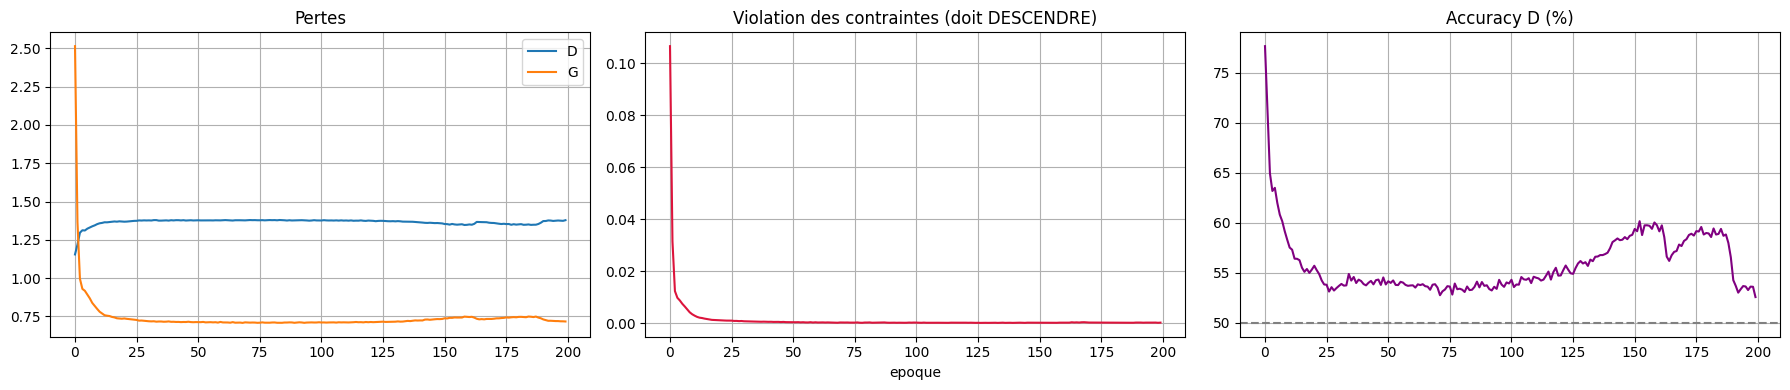


[Cellule 7 OK]


In [ ]:
# =====================================================================
# CELLULE 7 - ENTRAINEMENT DU cGAN
# =====================================================================
# Instancie G et D conditionnels et lance l'entrainement.
# Surveille G_constraint (doit descendre = G respecte les prompts).
#
# lambda_constraint : le bouton de reglage. Plus haut = respect plus
# strict. 15 est un bon point de depart.
# =====================================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# Instancier G et D conditionnels
G_cond = ConditionalGenerator(latent_dim=32, cond_dim=18,
                              out_dim=len(GENERATIVE_ROOMS)).to(device)
D_cond = ConditionalDiscriminator(vector_dim=len(GENERATIVE_ROOMS),
                                  cond_dim=18).to(device)

print(f"G: {sum(p.numel() for p in G_cond.parameters()):,} params")
print(f"D: {sum(p.numel() for p in D_cond.parameters()):,} params")

# Entrainement
EPOCHS = 200
LAMBDA = 15.0

hist = train_cgan(G_cond, D_cond, cond_dataloader, device, MAX_VEC,
                  epochs=EPOCHS, lr=2e-4, lambda_constraint=LAMBDA,
                  checkpoint_dir=MODEL_DIR, checkpoint_every=25, log_every=10)

# Sauvegarde finale
final_path = os.path.join(MODEL_DIR, "cgan_final.pt")
torch.save({
    "G": G_cond.state_dict(), "D": D_cond.state_dict(),
    "latent_dim": 32, "cond_dim": 18,
    "max_per_room": max_per_room, "room_names": GENERATIVE_ROOMS,
}, final_path)
print(f"\nModele final: {final_path}")

# Courbes
plot_history(hist)
print("\n[Cellule 7 OK]")


## Cellule 6 — Le prompter !

In [ ]:
# =====================================================================
# WRAPPER SIMPLIFIE - plan() en une ligne
# =====================================================================
# Enrobe plan_from_prompt en capturant l'environnement global, pour
# pouvoir ecrire simplement : plan("T3 avec balcon", n=3)
# =====================================================================

def plan(prompt, n=1, snap=True, seed=None, show=True, save_dir=None):
    """Genere un ou plusieurs plans a partir d'un prompt texte.

    Exemples :
      plan("T3 avec balcon")
      plan("T4 avec 2 douches et un bureau", n=3)
      plan("studio lumineux", show=False, save_dir="/content/drive/MyDrive/plans")
    """
    return plan_from_prompt(
        prompt=prompt,
        G=G_cond,                      # generateur conditionnel entraine
        max_vec=MAX_VEC,
        room_names=GENERATIVE_ROOMS,
        place_rooms_fn=place_rooms,
        place_rooms_compact_fn=place_rooms_compact,
        room_ids_map=room_ids,
        id_to_room_map=id_to_room,
        adjacencies=room_adjacencies,
        render_fn=render_architectural_plan,
        parse_fn=parse_prompt,
        make_cond_fn=make_condition_from_constraints,
        n_variants=n, snap=snap, seed=seed, show=show, save_dir=save_dir,
    )


### Exemples

Prompt   : "T3 avec balcon"
Contraintes imposees : {'salon': 1, 'chambre': 2, 'cuisine': 1, 'balcon': 1}


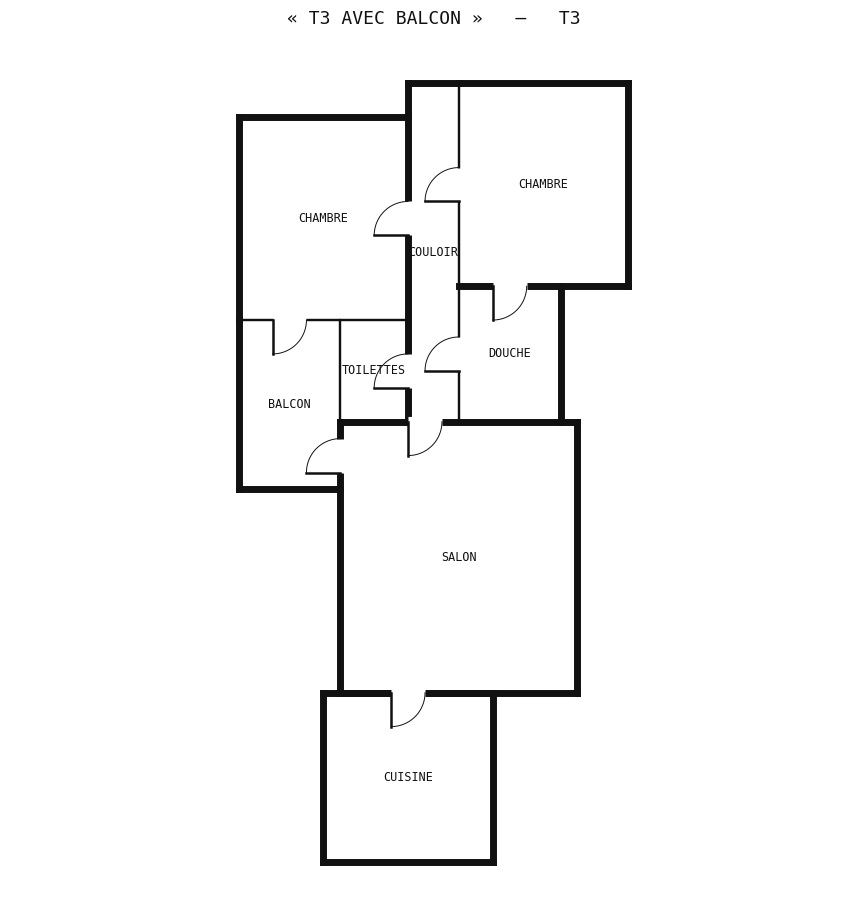

  Variante 1: {'salon': 1, 'chambre': 2, 'douche': 1, 'toilettes': 1, 'couloir': 1, 'cuisine': 1, 'balcon': 1}
Prompt   : "T4 avec 2 douches et un bureau"
Contraintes imposees : {'salon': 1, 'chambre': 3, 'douche': 2, 'bureau': 1, 'cuisine': 1}


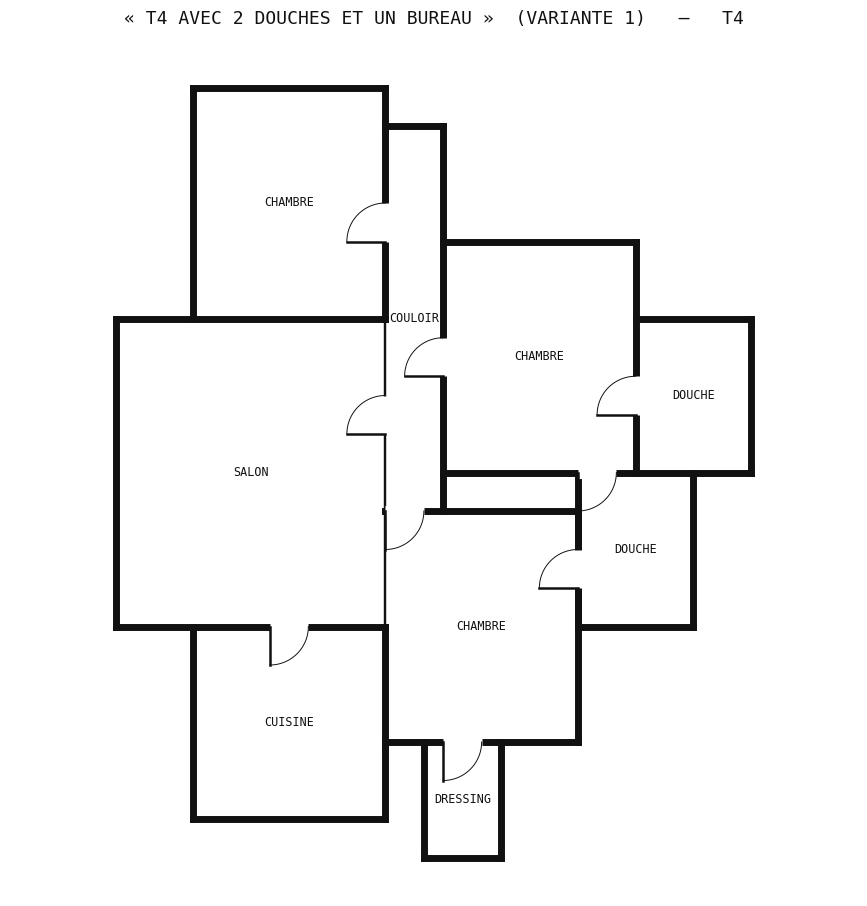

  Variante 1: {'salon': 1, 'chambre': 3, 'douche': 2, 'toilettes': 1, 'couloir': 1, 'bureau': 1, 'cuisine': 1, 'dressing': 1}


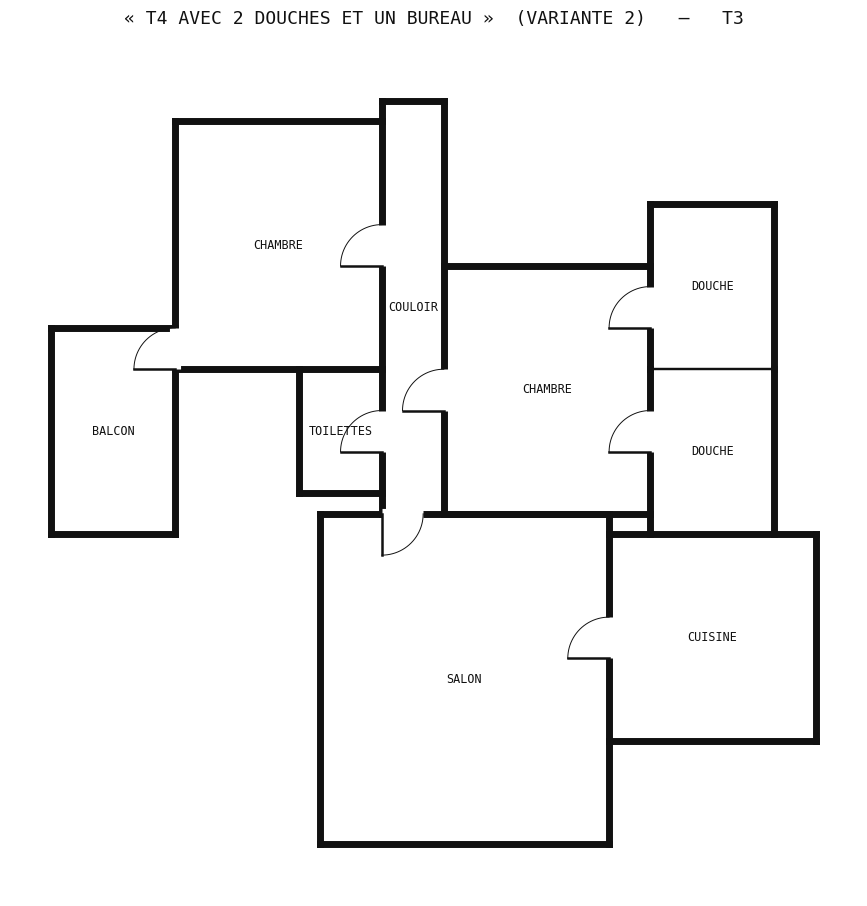

  Variante 2: {'salon': 1, 'chambre': 3, 'douche': 2, 'toilettes': 1, 'couloir': 1, 'bureau': 1, 'cuisine': 1, 'balcon': 1}


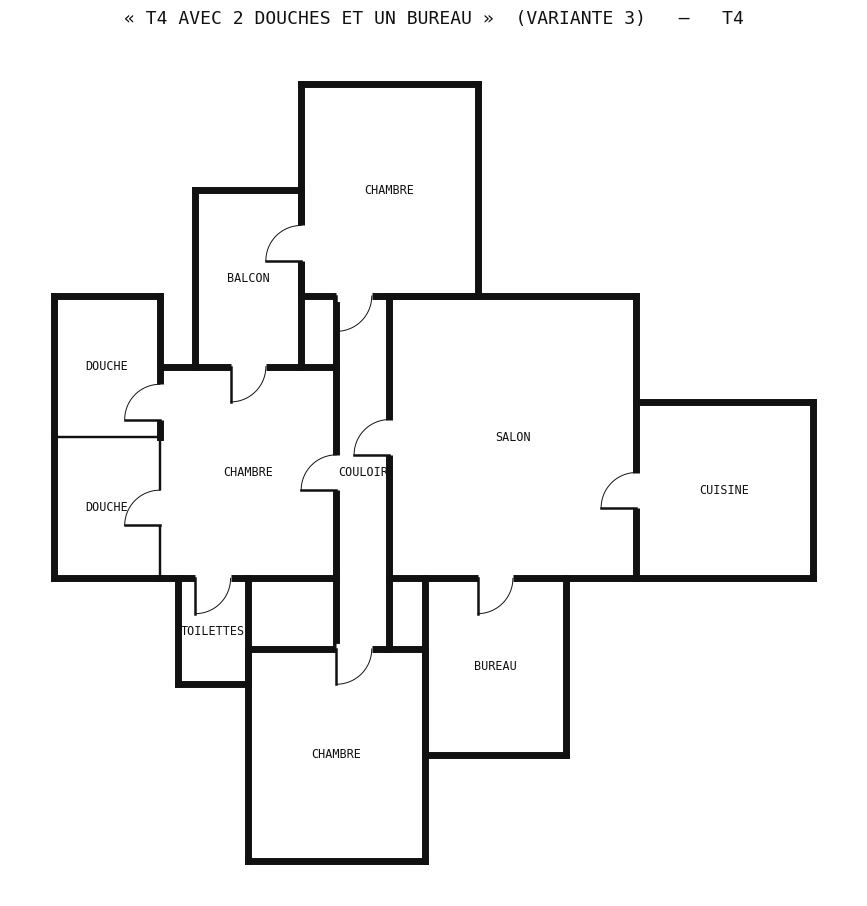

  Variante 3: {'salon': 1, 'chambre': 3, 'douche': 2, 'toilettes': 1, 'couloir': 1, 'bureau': 1, 'cuisine': 1, 'balcon': 1}
Prompt   : "appart 5 chambres sans balcon"
Contraintes imposees : {'salon': 1, 'chambre': 5, 'cuisine': 1, 'balcon': 0}


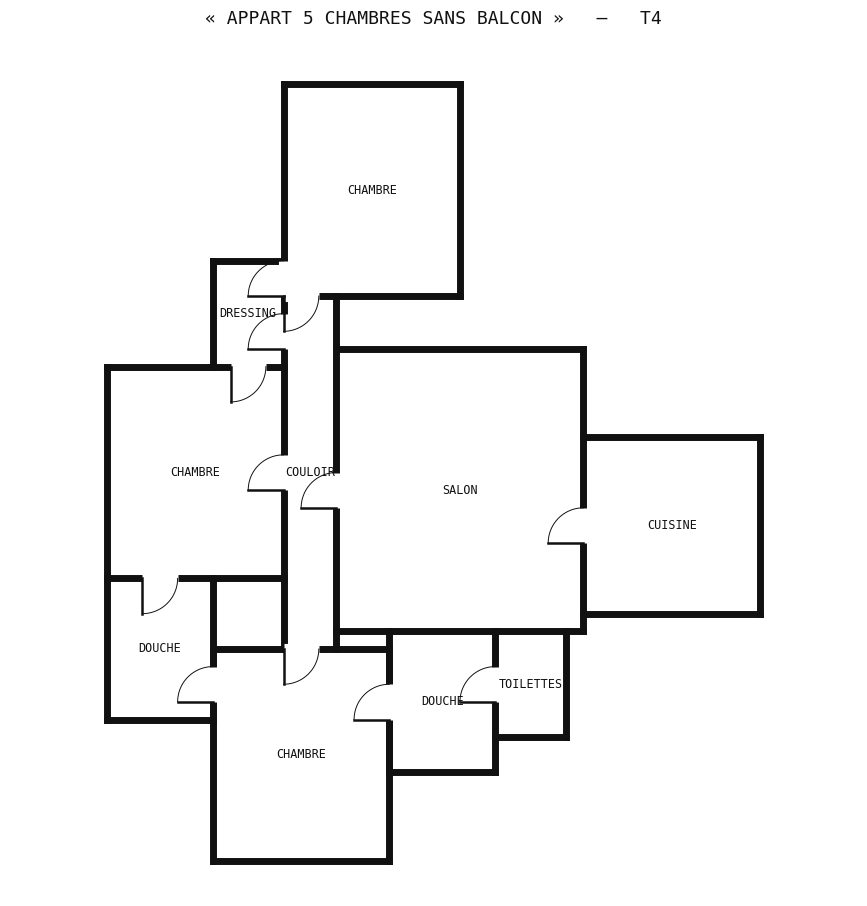

  Variante 1: {'salon': 1, 'chambre': 5, 'douche': 2, 'toilettes': 1, 'couloir': 1, 'cuisine': 1, 'dressing': 1}


[{'pieces': {'salon': 1,
   'chambre': 5,
   'douche': 2,
   'toilettes': 1,
   'couloir': 1,
   'cuisine': 1,
   'dressing': 1},
  'grid': array([[11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         ...,
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11]]),
  'placed': [{'id': 1,
    'pos': (24, 23, 14, 16),
    'name': 'salon',
    'unique_id': 'salon_0'},
   {'id': 5,
    'pos': (21, 20, 3, 20),
    'name': 'couloir',
    'unique_id': 'couloir_0'},
   {'id': 2,
    'pos': (17, 40, 10, 12),
    'name': 'chambre',
    'unique_id': 'chambre_0'},
   {'id': 2,
    'pos': (21, 8, 10, 12),
    'name': 'chambre',
    'unique_id': 'chambre_1'},
   {'id': 2,
    'pos': (11, 24, 10, 12),
    'name': 'chambre',
    'unique_id': 'chambre_2'},
   {'id': 8,
    'pos': (38, 28, 10, 10),
    'name': 'cuisine',
    'unique_id': 'cuisine_0'},
   {'id': 3, 'pos': (11, 3

In [ ]:
plan("T3 avec balcon")
plan("T4 avec 2 douches et un bureau", n=3)
plan("appart 5 chambres sans balcon")

Prompt   : "T4 avec 2 douches et un bureau"
Contraintes imposees : {'salon': 1, 'chambre': 3, 'douche': 2, 'bureau': 1, 'cuisine': 1}


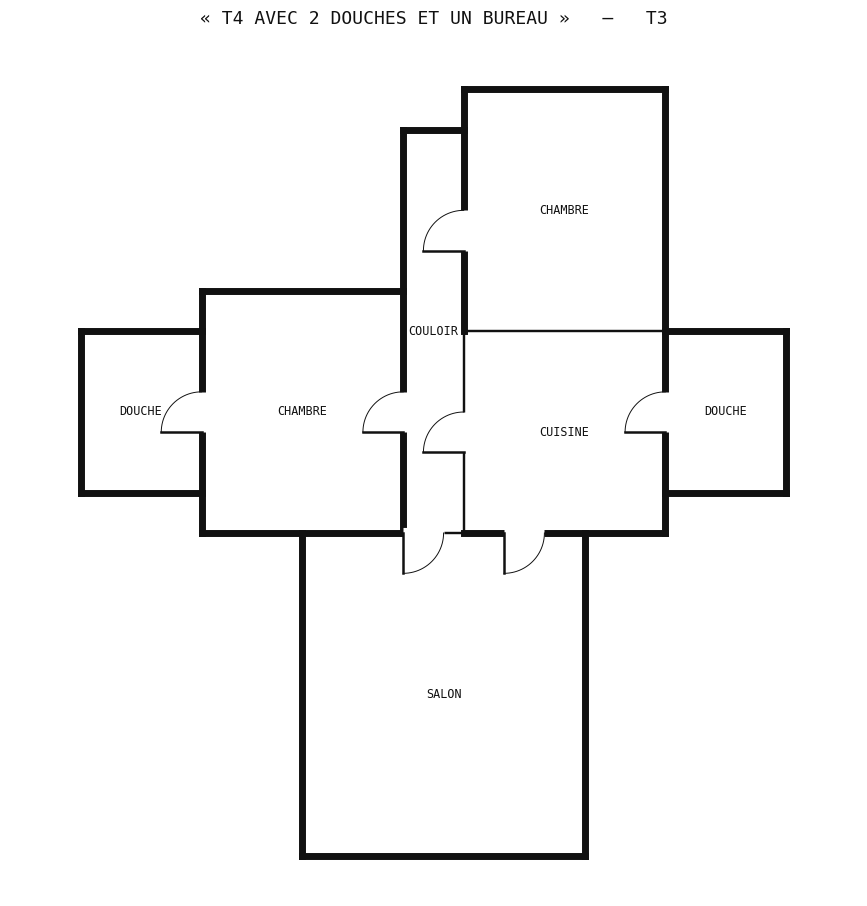

  Variante 1: {'salon': 1, 'chambre': 3, 'douche': 2, 'toilettes': 1, 'couloir': 1, 'bureau': 1, 'cuisine': 1}


[{'pieces': {'salon': 1,
   'chambre': 3,
   'douche': 2,
   'toilettes': 1,
   'couloir': 1,
   'bureau': 1,
   'cuisine': 1},
  'grid': array([[11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         ...,
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11]]),
  'placed': [{'id': 1,
    'pos': (23, 33, 14, 16),
    'name': 'salon',
    'unique_id': 'salon_0'},
   {'id': 5,
    'pos': (28, 13, 3, 20),
    'name': 'couloir',
    'unique_id': 'couloir_0'},
   {'id': 2,
    'pos': (31, 11, 10, 12),
    'name': 'chambre',
    'unique_id': 'chambre_0'},
   {'id': 2,
    'pos': (18, 21, 10, 12),
    'name': 'chambre',
    'unique_id': 'chambre_1'},
   {'id': 8,
    'pos': (31, 23, 10, 10),
    'name': 'cuisine',
    'unique_id': 'cuisine_0'},
   {'id': 3, 'pos': (41, 23, 6, 8), 'name': 'douche', 'unique_id': 'douche_0'},
   {'id': 3,
    'pos': (12, 23, 6, 8),
   

In [ ]:
plan("T4 avec 2 douches et un bureau")

Prompt   : "Un salon , deux chambre , une douche "
Contraintes imposees : {'salon': 1, 'chambre': 2, 'douche': 1, 'cuisine': 1}


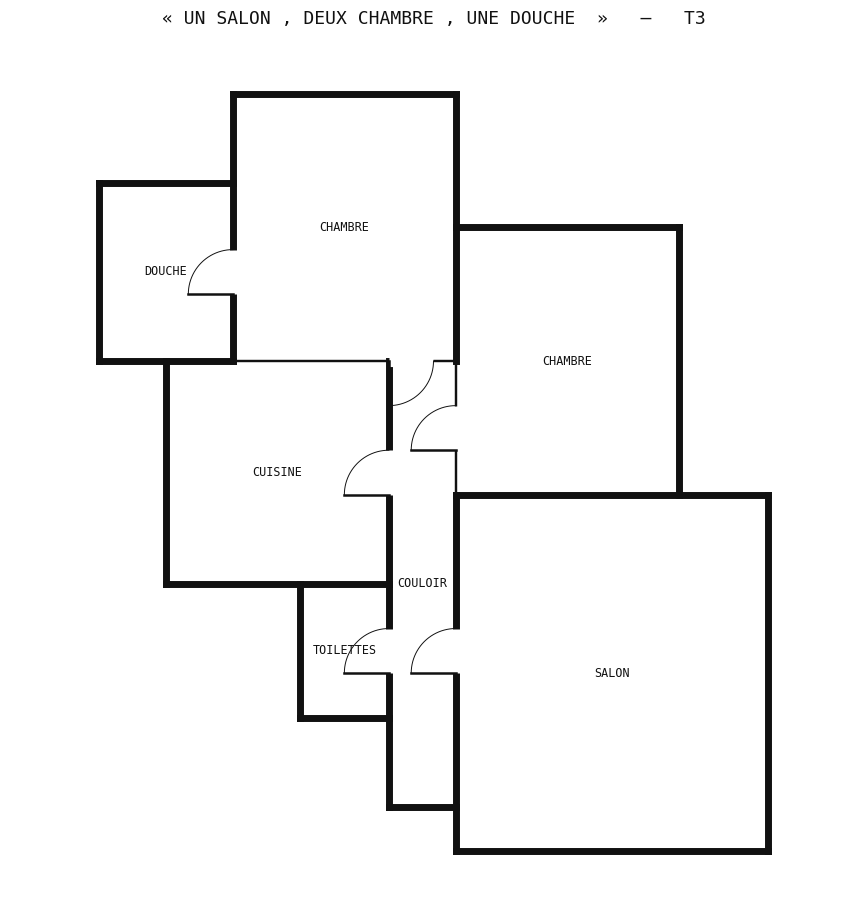

  Variante 1: {'salon': 1, 'chambre': 2, 'douche': 1, 'toilettes': 1, 'couloir': 1, 'cuisine': 1}


[{'pieces': {'salon': 1,
   'chambre': 2,
   'douche': 1,
   'toilettes': 1,
   'couloir': 1,
   'cuisine': 1},
  'grid': array([[11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         ...,
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11]]),
  'placed': [{'id': 1,
    'pos': (31, 31, 14, 16),
    'name': 'salon',
    'unique_id': 'salon_0'},
   {'id': 5,
    'pos': (28, 25, 3, 20),
    'name': 'couloir',
    'unique_id': 'couloir_0'},
   {'id': 2,
    'pos': (31, 19, 10, 12),
    'name': 'chambre',
    'unique_id': 'chambre_0'},
   {'id': 2,
    'pos': (21, 13, 10, 12),
    'name': 'chambre',
    'unique_id': 'chambre_1'},
   {'id': 8,
    'pos': (18, 25, 10, 10),
    'name': 'cuisine',
    'unique_id': 'cuisine_0'},
   {'id': 3, 'pos': (15, 17, 6, 8), 'name': 'douche', 'unique_id': 'douche_0'},
   {'id': 4,
    'pos': (24, 35, 4, 6),
    'name': 'toilet

In [ ]:
plan("Un salon , deux chambre , une douche ")

Prompt   : "T4 avec 2 douches et un bureau"
Contraintes imposees : {'salon': 1, 'chambre': 3, 'douche': 2, 'bureau': 1, 'cuisine': 1}


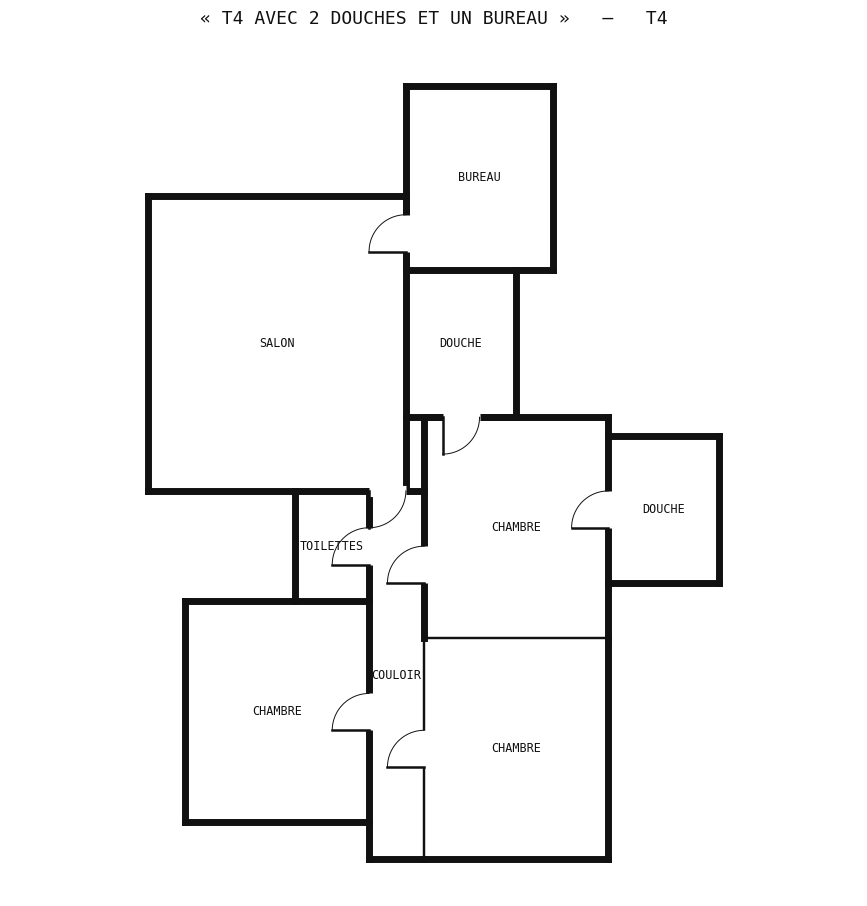

  Variante 1: {'salon': 1, 'chambre': 3, 'douche': 2, 'toilettes': 1, 'couloir': 1, 'bureau': 1, 'cuisine': 1}


[{'pieces': {'salon': 1,
   'chambre': 3,
   'douche': 2,
   'toilettes': 1,
   'couloir': 1,
   'bureau': 1,
   'cuisine': 1},
  'grid': array([[11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         ...,
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11],
         [11, 11, 11, ..., 11, 11, 11]]),
  'placed': [{'id': 1,
    'pos': (14, 15, 14, 16),
    'name': 'salon',
    'unique_id': 'salon_0'},
   {'id': 5,
    'pos': (26, 31, 3, 20),
    'name': 'couloir',
    'unique_id': 'couloir_0'},
   {'id': 2,
    'pos': (16, 37, 10, 12),
    'name': 'chambre',
    'unique_id': 'chambre_0'},
   {'id': 2,
    'pos': (29, 39, 10, 12),
    'name': 'chambre',
    'unique_id': 'chambre_1'},
   {'id': 2,
    'pos': (29, 27, 10, 12),
    'name': 'chambre',
    'unique_id': 'chambre_2'},
   {'id': 3, 'pos': (39, 28, 6, 8), 'name': 'douche', 'unique_id': 'douche_0'},
   {'id': 3, 'pos': (28, 19, 6, 8), 'name':

In [ ]:
plan("T4 avec 2 douches et un bureau")